TASK1

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

In [3]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialise weights and bias
np.random.seed(42)
w = np.random.randn(30) * 0.01
b = np.random.randn() * 0.01

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Single-neuron forward pass
def forward(x, w, b):
    return sigmoid(np.dot(w, x) + b)

# Run on first 5 test rows
predictions = [forward(x, w, b) for x in X_test[:5]]

print("Predicted probabilities:")
for i, p in enumerate(predictions, 1):
    print(f"Row {i}: {p:.6f}")

Predicted probabilities:
Row 1: 0.496225
Row 2: 0.517540
Row 3: 0.507080
Row 4: 0.487440
Row 5: 0.483946


This implements a single-neuron logistic regression model (equivalently, a perceptron with a sigmoid activation).

TASK2

In [4]:
class NumpyMLP:
    def __init__(self, input_size=30, hidden_size=8, output_size=1):
        np.random.seed(42)

        # He initialisation
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size)
        self.b2 = np.zeros((1, output_size))

    def relu(self, z):
        return np.maximum(0, z)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        # Hidden layer
        z1 = X @ self.W1 + self.b1
        a1 = self.relu(z1)

        # Output layer
        z2 = a1 @ self.W2 + self.b2
        y_hat = self.sigmoid(z2)

        return y_hat


mlp = NumpyMLP()

predictions = mlp.forward(X_test)

# Print results
print("Output shape:", predictions.shape)

print("\nFirst 5 predictions:")
print(predictions[:5])

Output shape: (114, 1)

First 5 predictions:
[[0.45299955]
 [0.46601069]
 [0.56604814]
 [0.40817775]
 [0.36364703]]


Even before training, the network outputs shape (N, 1) because the final layer is designed to produce one probability-like value per sample, which is exactly the format needed for binary classification.

In [5]:
mlp

In [6]:
numpy_model=mlp
numpy_model

TASK3

In [7]:
import torch
import torch.nn as nn

In [8]:
class TorchMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(30, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x


torch_model = TorchMLP()

# =========================================================
# Copy NumPy weights into PyTorch model
# IMPORTANT:
# nn.Linear stores weights as (out_features, in_features)
# =========================================================
torch_model.fc1.weight.data = torch.from_numpy(
    numpy_model.W1.T
).float()

torch_model.fc1.bias.data = torch.from_numpy(
    numpy_model.b1.flatten()
).float()

torch_model.fc2.weight.data = torch.from_numpy(
    numpy_model.W2.T
).float()

torch_model.fc2.bias.data = torch.from_numpy(
    numpy_model.b2.flatten()
).float()

# =========================================================
# Run forward pass in PyTorch
# =========================================================
X_test_tensor = torch.from_numpy(X_test).float()

with torch.no_grad():
    torch_preds = torch_model(X_test_tensor).numpy()

# =========================================================
# Compare outputs
# =========================================================
max_abs_diff = np.max(np.abs(predictions - torch_preds))

print("NumPy predictions (first 5):")
print(predictions[:5])

print("\nPyTorch predictions (first 5):")
print(torch_preds[:5])

print("\nMaximum absolute difference:")
print(max_abs_diff)

NumPy predictions (first 5):
[[0.45299955]
 [0.46601069]
 [0.56604814]
 [0.40817775]
 [0.36364703]]

PyTorch predictions (first 5):
[[0.45299956]
 [0.4660107 ]
 [0.56604815]
 [0.40817776]
 [0.363647  ]]

Maximum absolute difference:
6.359250637189007e-08


TASK4

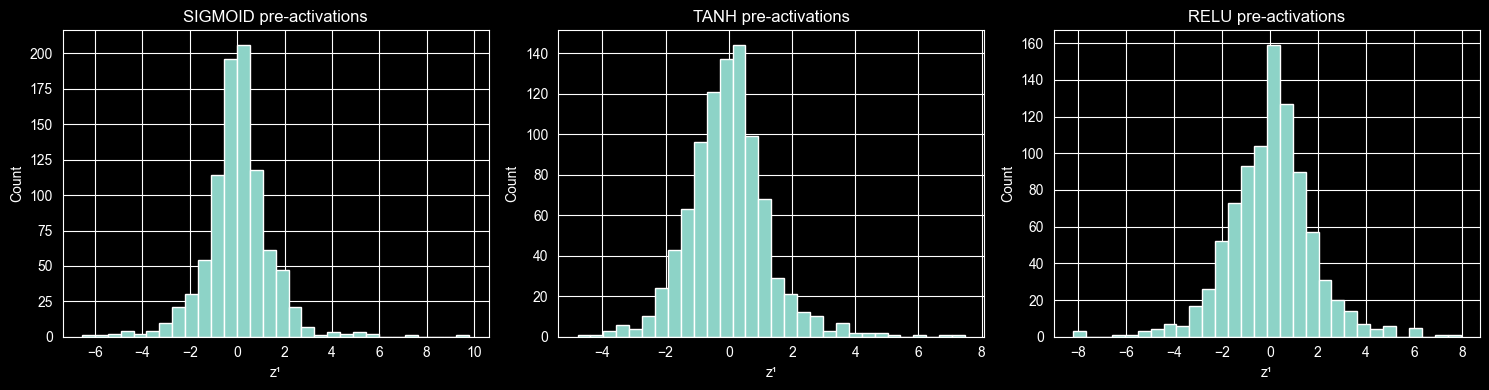

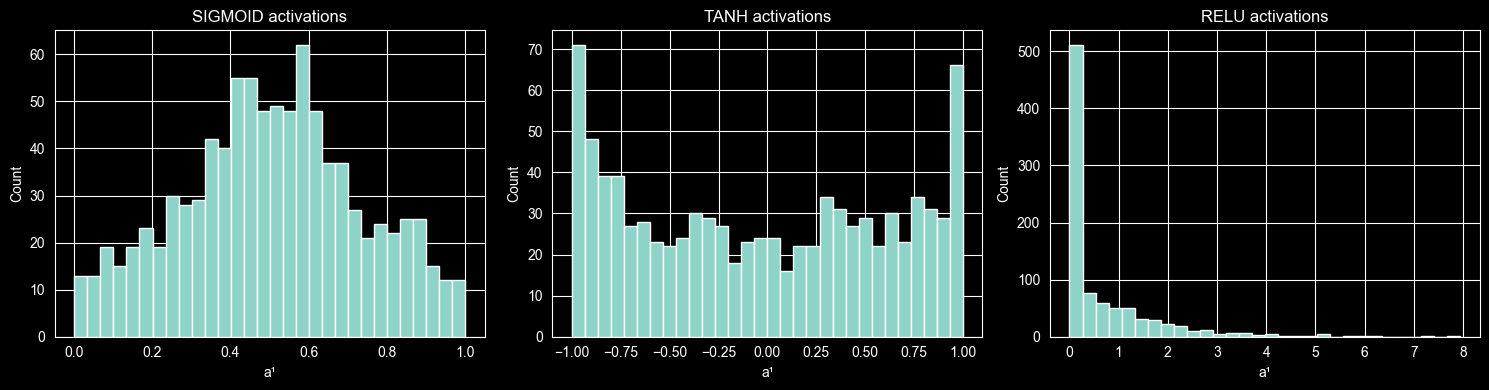

Sigmoid saturation fraction: 0.043
Tanh saturation fraction:    0.121
ReLU inactive fraction:      0.462


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# =========================================================
# Activation experiment model
# =========================================================
class ActivationMLP(nn.Module):
    def __init__(self, activation="relu"):
        super().__init__()

        self.fc1 = nn.Linear(30, 8)
        self.fc2 = nn.Linear(8, 1)

        # He initialisation
        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity='relu')
        nn.init.zeros_(self.fc1.bias)

        nn.init.kaiming_normal_(self.fc2.weight, nonlinearity='relu')
        nn.init.zeros_(self.fc2.bias)

        if activation == "sigmoid":
            self.activation = nn.Sigmoid()
        elif activation == "tanh":
            self.activation = nn.Tanh()
        else:
            self.activation = nn.ReLU()

        self.output_activation = nn.Sigmoid()

    def forward(self, x):
        z1 = self.fc1(x)          # pre-activation
        a1 = self.activation(z1)  # post-activation

        z2 = self.fc2(a1)
        y_hat = self.output_activation(z2)

        return y_hat, z1, a1


# =========================================================
# Prepare input batch
# =========================================================
X_batch = torch.from_numpy(X_test).float()

# =========================================================
# Create models
# =========================================================
activations = ["sigmoid", "tanh", "relu"]

results = {}

for act in activations:
    model = ActivationMLP(activation=act)

    with torch.no_grad():
        preds, z1, a1 = model(X_batch)

    results[act] = {
        "z1": z1.numpy(),
        "a1": a1.numpy(),
        "preds": preds.numpy()
    }

# =========================================================
# Plot pre-activations
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, act in zip(axes, activations):
    ax.hist(results[act]["z1"].flatten(), bins=30)
    ax.set_title(f"{act.upper()} pre-activations")
    ax.set_xlabel("z¹")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

# =========================================================
# Plot post-activations
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, act in zip(axes, activations):
    ax.hist(results[act]["a1"].flatten(), bins=30)
    ax.set_title(f"{act.upper()} activations")
    ax.set_xlabel("a¹")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

# =========================================================
# Saturation / inactivity statistics
# =========================================================

# Sigmoid saturation:
# close to 0 or 1
sigmoid_vals = results["sigmoid"]["a1"]
sigmoid_saturated = np.mean(
    (sigmoid_vals < 0.05) | (sigmoid_vals > 0.95)
)

# Tanh saturation:
# close to -1 or +1
tanh_vals = results["tanh"]["a1"]
tanh_saturated = np.mean(
    (tanh_vals < -0.95) | (tanh_vals > 0.95)
)

# ReLU inactivity:
# exactly 0
relu_vals = results["relu"]["a1"]
relu_inactive = np.mean(relu_vals == 0)

print(f"Sigmoid saturation fraction: {sigmoid_saturated:.3f}")
print(f"Tanh saturation fraction:    {tanh_saturated:.3f}")
print(f"ReLU inactive fraction:      {relu_inactive:.3f}")

### Observations

- Sigmoid activations compress values into the range (0, 1). Many outputs can become very close to 0 or 1, which places them in the saturated region where gradients become extremely small.
- Tanh activations similarly saturate near -1 and +1, also causing vanishing gradients.
- ReLU outputs exactly 0 for all negative inputs, so a fraction of units become inactive, but positive activations remain unsaturated and preserve strong gradients.

### Why ReLU is usually the better default

ReLU avoids the severe saturation problem seen in Sigmoid and Tanh for positive activations. This helps gradients propagate more effectively through deep networks, making optimisation faster and more stable in practice.